In [ ]:
## What this notebook does
Analyzes what percentage of users return to purchase in months following their first purchase, grouped by acquisition cohort.

## Why it matters
Retention is the primary indicator of product health — declining retention means users aren't finding long-term value.

## Key finding
Retention stabilizes at 11-13% by month 4-5 across all cohorts, with December and March cohorts showing weaker month 1 retention 
consistent with seasonal buying behavior.

In [3]:
# imports and connection
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake_config import SNOWFLAKE_CONFIG

conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
cursor = conn.cursor()

def run_query(sql):
    cursor.execute(sql)
    df = cursor.fetch_pandas_all()
    return df

print("Connected!")

Connected!


In [5]:
cohort_df = run_query("""
    with first_purchase as (
        select
            user_id,
            cast(date_trunc('month', min(event_time)) as date) as cohort_month
        from fct_purchases
        group by 1
    ),

    user_purchases as (
        select
            user_id,
            cast(date_trunc('month', event_time) as date) as purchase_month
        from fct_purchases
        group by 1, 2
    ),

    cohort_data as (
        select
            f.cohort_month,
            u.purchase_month,
            datediff(
                'month',
                f.cohort_month,
                u.purchase_month
            )                          as months_since_cohort,
            count(distinct u.user_id)  as users
        from first_purchase f
        left join user_purchases u
            on f.user_id = u.user_id
        group by 1, 2, 3
    ),

    cohort_sizes as (
        select
            cohort_month,
            users as cohort_size
        from cohort_data
        where months_since_cohort = 0
    )

    select
        c.cohort_month,
        c.months_since_cohort,
        c.users,
        s.cohort_size,
        round(c.users * 100.0 / s.cohort_size, 2) as retention_pct
    from cohort_data c
    left join cohort_sizes s
        on c.cohort_month = s.cohort_month
    where c.months_since_cohort >= 0
    order by 1, 2
""")

cohort_df.head(20)

,COHORT_MONTH,MONTHS_SINCE_COHORT,USERS,COHORT_SIZE,RETENTION_PCT
0,2019-10-01,0,346141,346141,100.00
1,2019-10-01,1,90971,346141,26.28
2,2019-10-01,2,76130,346141,21.99
3,2019-10-01,3,47336,346141,13.68
4,2019-10-01,4,44080,346141,12.73
5,2019-10-01,5,42323,346141,12.23
6,2019-10-01,6,27924,346141,8.07
7,2019-10-01,7,301,346141,0.09
8,2019-11-01,0,349618,349618,100.00
9,2019-11-01,1,77564,349618,22.19


In [22]:
# find each cohort's maximum month
max_month_per_cohort = cohort_df_clean.groupby(
    'COHORT_MONTH'
)['MONTHS_SINCE_COHORT'].max().reset_index()
max_month_per_cohort.columns = ['COHORT_MONTH', 'MAX_MONTH']

# merge and filter out last month per cohort
cohort_df_clean = cohort_df_clean.merge(
    max_month_per_cohort, 
    on='COHORT_MONTH'
)
cohort_df_clean = cohort_df_clean[
    cohort_df_clean['MONTHS_SINCE_COHORT'] < cohort_df_clean['MAX_MONTH']
].drop(columns='MAX_MONTH')

# rebuild pivot
cohort_pivot = cohort_df_clean.pivot_table(
    index='COHORT_MONTH',
    columns='MONTHS_SINCE_COHORT',
    values='RETENTION_PCT'
)

cohort_pivot.index = pd.to_datetime(
    cohort_pivot.index
).strftime('%Y-%m')

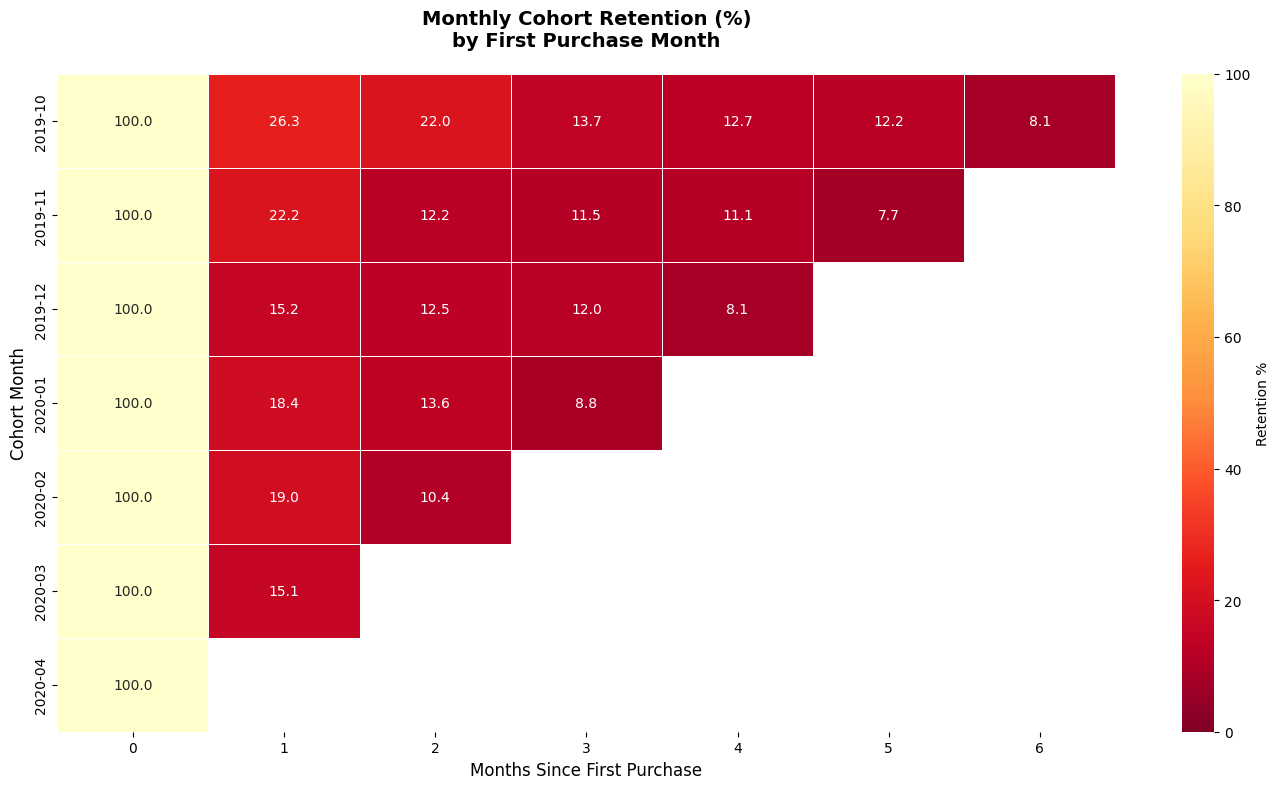

In [23]:
# draw the heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    cohort_pivot.astype(float),  # ← this fixes it
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention %'}
)

ax.set_title(
    'Monthly Cohort Retention (%)\nby First Purchase Month',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)

plt.tight_layout()
plt.show()

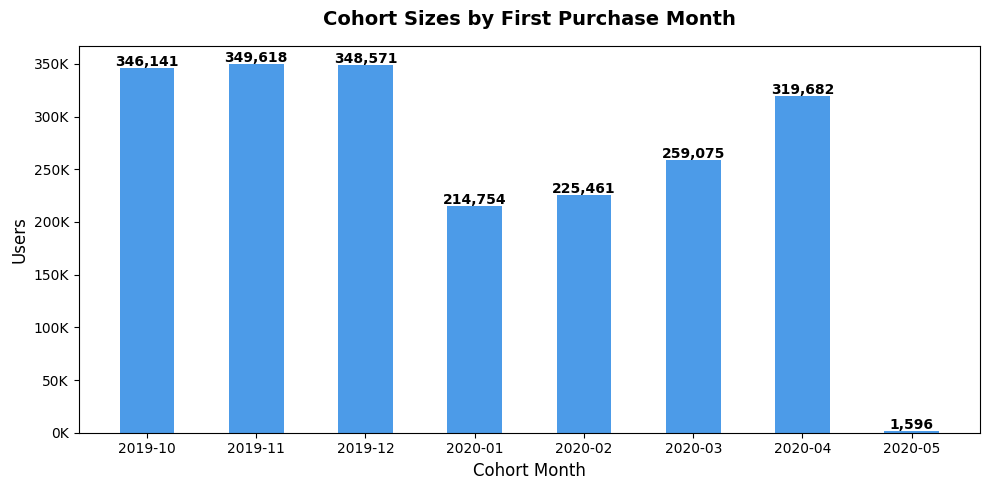

In [24]:
cohort_sizes = cohort_df[
    cohort_df['MONTHS_SINCE_COHORT'] == 0
][['COHORT_MONTH', 'COHORT_SIZE']].copy()

cohort_sizes['COHORT_MONTH'] = pd.to_datetime(
    cohort_sizes['COHORT_MONTH']
).dt.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    cohort_sizes['COHORT_MONTH'],
    cohort_sizes['COHORT_SIZE'],
    color='#4C9BE8',
    width=0.5
)

for i, (_, row) in enumerate(cohort_sizes.iterrows()):
    ax.text(
        i,
        row['COHORT_SIZE'] + 2000,
        f"{row['COHORT_SIZE']:,.0f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Cohort Sizes by First Purchase Month',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Cohort Month', fontsize=12)
ax.set_ylabel('Users', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

In [ ]:
## Retention Insights

'''Retention across cohorts ranges from 15% to 26% in month 1, 
stabilizing at 11-13% by months 4-5. This flattening indicates 
a loyal core user base of roughly 12% of converted users.

December and March cohorts show notably weaker month 1 retention, 
consistent with the holiday buyer effect — seasonal purchasers 
who buy for a specific occasion but have lower long-term product affinity.

Recommendation: Launch targeted re-engagement campaigns within 
2 weeks after the first purchase, particularly for December and March cohorts. 
Personalized post-purchase recommendations could help convert 
seasonal buyers into repeat customers during the critical 
month 1 window.'''